## Reading data (same as always)
Load detided U and V current components from NetCDF files using xarray.


In [166]:
import xarray as xr
import pandas as pd
import numpy as np

uo = xr.open_dataset("../data/raw/adriatic_currents_uo_detided_2023_2024.nc")
vo = xr.open_dataset("../data/raw/adriatic_currents_vo_detided_2023_2024.nc")


In [ ]:
# Drop NaNs and merge UO/VO into a single DataFrame aligned by lon/lat/time.
def drop_na_and_marge(uo_sub, vo_sub):
    vo_sub = vo_sub[["longitude", "latitude", "vo_detided"]].to_dataframe()
    uo_sub = uo_sub[["longitude", "latitude", "uo_detided"]].to_dataframe()
    
    mask = (~vo_sub["vo_detided"].isna()) | (~uo_sub["uo_detided"].isna())
    vo_sub_filter = vo_sub[mask].reset_index() 
    uo_sub_filter = uo_sub[mask].reset_index()

    base_col = ["longitude", "latitude", "time"]
    assert (uo_sub_filter[base_col].to_numpy() == vo_sub_filter[base_col].to_numpy()).all()
 
    return pd.merge(
        uo_sub_filter, 
        vo_sub_filter, 
        on=base_col,
        # suffixes=('_uo', '_vo')
    )


df = drop_na_and_marge(uo, vo)

In [168]:
df

,longitude,latitude,time,uo_detided,vo_detided
0,12.000000,40.020832,2023-01-01,0.017013,-0.066594
1,12.000000,40.020832,2023-01-02,0.011754,-0.064362
2,12.000000,40.020832,2023-01-03,-0.021662,-0.063423
3,12.000000,40.020832,2023-01-04,-0.101635,-0.056278
4,12.000000,40.020832,2023-01-05,-0.093153,-0.030500
...,...,...,...,...,...
7785876,19.833334,40.020832,2024-12-27,0.017602,-0.042690
7785877,19.833334,40.020832,2024-12-28,0.013208,-0.034532
7785878,19.833334,40.020832,2024-12-29,0.010109,-0.023585
7785879,19.833334,40.020832,2024-12-30,0.003321,-0.011271


## Build spatial nodes
Extract unique (longitude, latitude) points and assign node IDs.


In [ ]:
import pandas as pd
import numpy as np

nodes = (
    df[['longitude', 'latitude']]
    .drop_duplicates()
    .reset_index(drop=True)
)

N = len(nodes)
print(f"Liczba węzłów: {N}")

node_id = {
    (row.longitude, row.latitude): i
    for i, row in nodes.iterrows()
}
node_id

Liczba węzłów: 10651


{(np.float32(12.0), np.float32(40.020832)): 0,
 (np.float32(12.0), np.float32(40.0625)): 1,
 (np.float32(12.0), np.float32(40.104168)): 2,
 (np.float32(12.0), np.float32(40.145832)): 3,
 (np.float32(12.0), np.float32(40.1875)): 4,
 (np.float32(12.0), np.float32(40.229168)): 5,
 (np.float32(12.0), np.float32(40.270832)): 6,
 (np.float32(12.0), np.float32(40.3125)): 7,
 (np.float32(12.0), np.float32(40.354168)): 8,
 (np.float32(12.0), np.float32(40.395832)): 9,
 (np.float32(12.0), np.float32(40.4375)): 10,
 (np.float32(12.0), np.float32(40.479168)): 11,
 (np.float32(12.0), np.float32(40.520832)): 12,
 (np.float32(12.0), np.float32(40.5625)): 13,
 (np.float32(12.0), np.float32(40.604168)): 14,
 (np.float32(12.0), np.float32(40.645832)): 15,
 (np.float32(12.0), np.float32(40.6875)): 16,
 (np.float32(12.0), np.float32(40.729168)): 17,
 (np.float32(12.0), np.float32(40.770832)): 18,
 (np.float32(12.0), np.float32(40.8125)): 19,
 (np.float32(12.0), np.float32(40.854168)): 20,
 (np.float32(12.

## Inspect grid structure
Check grid regularity and visualize sample node indices.


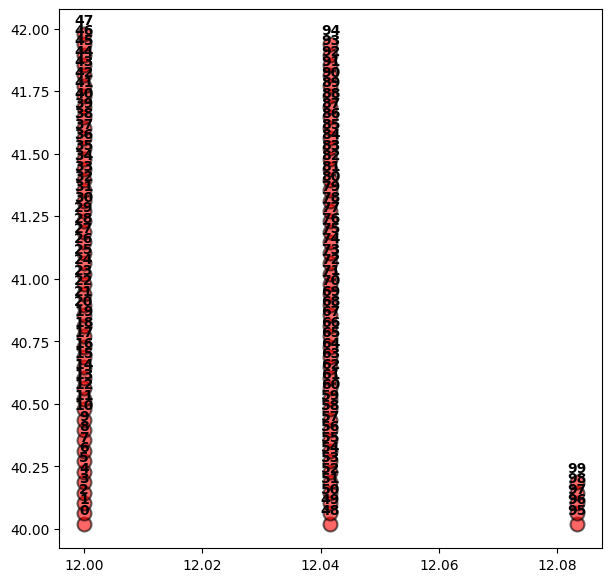

In [170]:
import matplotlib.pyplot as plt

# Konwersja do numpy
indices = nodes.index.values[:100]
longitudes = np.array(nodes["longitude"][:100])
latitudes = np.array(nodes["latitude"][:100])

# Wizualizacja
fig, ax = plt.subplots(figsize=(7, 7))

# Scatter plot
scatter = ax.scatter(longitudes, latitudes, c='red', s=100, alpha=0.6, edgecolors='black', linewidth=1.5)

# Podpisy indeksów
for i, idx in enumerate(indices):
    ax.annotate(str(idx), 
                (longitudes[i], latitudes[i]),
                fontsize=10,
                fontweight='bold',
                ha='center',
                va='bottom',
                xytext=(0, 5),
                textcoords='offset points')

In [171]:
lons = np.sort(nodes.longitude.unique())
lats = np.sort(nodes.latitude.unique())

dlon = np.unique(np.diff(lons))
dlat = np.unique(np.diff(lats))

print("Δlon:", dlon[:5])
print("Δlat:", dlat[:5])


Δlon: [0.04166603 0.04166698 0.04166794]
Δlat: [0.04166412 0.04166794]


In [ ]:
lon_vals = np.sort(lons)
lat_vals = np.sort(lats)

lon_to_i = {lon: i for i, lon in enumerate(lon_vals)}
lat_to_j = {lat: j for j, lat in enumerate(lat_vals)}

# Map (lon, lat) to quasi-regular grid indices (i, j).
grid = {}
for idx, row in nodes.iterrows():
    i = lon_to_i[row.longitude]
    j = lat_to_j[row.latitude]
    grid[(i, j)] = idx
grid


{(0, 0): 0,
 (0, 1): 1,
 (0, 2): 2,
 (0, 3): 3,
 (0, 4): 4,
 (0, 5): 5,
 (0, 6): 6,
 (0, 7): 7,
 (0, 8): 8,
 (0, 9): 9,
 (0, 10): 10,
 (0, 11): 11,
 (0, 12): 12,
 (0, 13): 13,
 (0, 14): 14,
 (0, 15): 15,
 (0, 16): 16,
 (0, 17): 17,
 (0, 18): 18,
 (0, 19): 19,
 (0, 20): 20,
 (0, 21): 21,
 (0, 22): 22,
 (0, 23): 23,
 (0, 24): 24,
 (0, 25): 25,
 (0, 26): 26,
 (0, 27): 27,
 (0, 28): 28,
 (0, 29): 29,
 (0, 30): 30,
 (0, 31): 31,
 (0, 32): 32,
 (0, 33): 33,
 (0, 34): 34,
 (0, 35): 35,
 (0, 36): 36,
 (0, 37): 37,
 (0, 38): 38,
 (0, 39): 39,
 (0, 40): 40,
 (0, 41): 41,
 (0, 42): 42,
 (0, 43): 43,
 (0, 44): 44,
 (0, 45): 45,
 (0, 46): 46,
 (0, 47): 47,
 (1, 0): 48,
 (1, 1): 49,
 (1, 2): 50,
 (1, 3): 51,
 (1, 4): 52,
 (1, 5): 53,
 (1, 6): 54,
 (1, 7): 55,
 (1, 8): 56,
 (1, 9): 57,
 (1, 10): 58,
 (1, 11): 59,
 (1, 12): 60,
 (1, 13): 61,
 (1, 14): 62,
 (1, 15): 63,
 (1, 16): 64,
 (1, 17): 65,
 (1, 18): 66,
 (1, 19): 67,
 (1, 20): 68,
 (1, 21): 69,
 (1, 22): 70,
 (1, 23): 71,
 (1, 24): 72,
 (1, 25)

## Construct graph edges
Create spatial edges using 8-neighborhood connectivity.

**Here you can uncommend the next code to get not the closest 8-neighborhood connectivity, but to get further neighbors within a specified radius**



In [ ]:
edges = []

for (i, j), u in grid.items():
    directions = [
        (-1, 0), (1, 0), (0, -1), (0, 1), # up, down, left, right
        (-1, -1), (-1, 1), (1, -1), (1, 1) # beveled edges
    ]
    
    for di, dj in directions:
    # for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
        ni, nj = i + di, j + dj
        if (ni, nj) in grid:
            v = grid[(ni, nj)]
            edges.append((u, v))


# radius = 15  # maximum distance from the node
# step = 5  # how often do we take neighbors
# edges = []

# for (i, j), u in grid.items():
#     # we go through all shifts in the radius x radius box
#     for di in range(-radius, radius + 1, step):
#         for dj in range(-radius, radius + 1, step):
#             if di == 0 and dj == 0:
#                 continue  # we ignore the knot with itself
#             ni, nj = i + di, j + dj
#             if (ni, nj) in grid:
#                 v = grid[(ni, nj)]
#                 edges.append((u, v))


edges

[(0, 48),
 (0, 1),
 (0, 49),
 (1, 49),
 (1, 0),
 (1, 2),
 (1, 48),
 (1, 50),
 (2, 50),
 (2, 1),
 (2, 3),
 (2, 49),
 (2, 51),
 (3, 51),
 (3, 2),
 (3, 4),
 (3, 50),
 (3, 52),
 (4, 52),
 (4, 3),
 (4, 5),
 (4, 51),
 (4, 53),
 (5, 53),
 (5, 4),
 (5, 6),
 (5, 52),
 (5, 54),
 (6, 54),
 (6, 5),
 (6, 7),
 (6, 53),
 (6, 55),
 (7, 55),
 (7, 6),
 (7, 8),
 (7, 54),
 (7, 56),
 (8, 56),
 (8, 7),
 (8, 9),
 (8, 55),
 (8, 57),
 (9, 57),
 (9, 8),
 (9, 10),
 (9, 56),
 (9, 58),
 (10, 58),
 (10, 9),
 (10, 11),
 (10, 57),
 (10, 59),
 (11, 59),
 (11, 10),
 (11, 12),
 (11, 58),
 (11, 60),
 (12, 60),
 (12, 11),
 (12, 13),
 (12, 59),
 (12, 61),
 (13, 61),
 (13, 12),
 (13, 14),
 (13, 60),
 (13, 62),
 (14, 62),
 (14, 13),
 (14, 15),
 (14, 61),
 (14, 63),
 (15, 63),
 (15, 14),
 (15, 16),
 (15, 62),
 (15, 64),
 (16, 64),
 (16, 15),
 (16, 17),
 (16, 63),
 (16, 65),
 (17, 65),
 (17, 16),
 (17, 18),
 (17, 64),
 (17, 66),
 (18, 66),
 (18, 17),
 (18, 19),
 (18, 65),
 (18, 67),
 (19, 67),
 (19, 18),
 (19, 20),
 (19, 66),


In [ ]:
# Graph representation (PyTorch Geometric)
# Convert edges to edge_index tensor requierds by PyTorch Geometric.

import torch

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
edge_index

tensor([[    0,     0,     0,  ..., 10649, 10649, 10650],
        [   48,     1,    49,  ..., 10650, 10648, 10649]])

## Edge features
Compute relative displacement, distance (haversine), and direction angle.

**You can try diffrent feture here as well**

In [175]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371000  # m
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

In [176]:
edge_feats = []

for u, v in edges:
    lon1, lat1 = nodes.loc[u, ['longitude', 'latitude']]
    lon2, lat2 = nodes.loc[v, ['longitude', 'latitude']]

    dx = lon2 - lon1
    dy = lat2 - lat1
    dist = haversine(lon1, lat1, lon2, lat2)
    angle = np.arctan2(dy, dx)

    edge_feats.append([dx, dy, dist, angle])

edge_attr = torch.tensor(edge_feats, dtype=torch.float)
edge_attr.shape

torch.Size([81664, 4])

In [177]:
edge_index.shape

torch.Size([2, 81664])

In [178]:
assert len(nodes) == len(node_id)


## Node feature construction
Build node features: U, V + cyclical time encodings.


In [ ]:
import numpy as np
import pandas as pd
import torch

def build_node_features(df_t, nodes, node_id):
    N = len(nodes)
    X = np.zeros((N, 6), dtype=np.float32)

    time = pd.to_datetime(df_t['time'].iloc[0])

    hour = time.hour + time.minute / 60
    doy = time.dayofyear

    sin_hour = np.sin(2 * np.pi * hour / 24)
    cos_hour = np.cos(2 * np.pi * hour / 24)
    sin_doy  = np.sin(2 * np.pi * doy / 365)
    cos_doy  = np.cos(2 * np.pi * doy / 365)

    for _, row in df_t.iterrows():
        idx = node_id[(row.longitude, row.latitude)]

        X[idx, 0] = row.uo_detided
        X[idx, 1] = row.vo_detided
        X[idx, 2] = sin_hour
        X[idx, 3] = cos_hour
        X[idx, 4] = sin_doy
        X[idx, 5] = cos_doy

    return torch.from_numpy(X)


In [180]:
t = pd.Timestamp("2023-01-10")

df_t = df[df.time == t]

X_t = build_node_features(df_t, nodes, node_id)

print(X_t.shape)


torch.Size([10651, 6])


In [ ]:
# Optimized node feature mapping
# Vectorized node feature construction via merge (faster).

def build_node_features_fast(df_t, nodes):
    df_t = df_t.merge(
        nodes.reset_index().rename(columns={'index': 'node_idx'}),
        on=['longitude', 'latitude'],
        how='left'
    )

    time = pd.to_datetime(df_t['time'].iloc[0])
    hour = time.hour + time.minute / 60
    doy = time.dayofyear

    sin_hour = np.sin(2 * np.pi * hour / 24)
    cos_hour = np.cos(2 * np.pi * hour / 24)
    sin_doy  = np.sin(2 * np.pi * doy / 365)
    cos_doy  = np.cos(2 * np.pi * doy / 365)

    N = len(nodes)
    X = np.zeros((N, 6), dtype=np.float32)

    X[df_t.node_idx, 0] = df_t.uo_detided.values
    X[df_t.node_idx, 1] = df_t.vo_detided.values
    X[:, 2] = sin_hour
    X[:, 3] = cos_hour
    X[:, 4] = sin_doy
    X[:, 5] = cos_doy

    return torch.from_numpy(X)

t = pd.Timestamp("2023-01-10")

df_t = df[df.time == t]

X_t = build_node_features_fast(df_t, nodes)

print(X_t.shape)


torch.Size([10651, 6])


# Normalization

**You cen try how it goes, without normalization**

In [ ]:
import torch
import numpy as np

all_features = []

for t in df['time'].unique():
    df_t = df[df.time == t]
    X_t = build_node_features_fast(df_t, nodes)
    all_features.append(X_t)

all_features = torch.stack(all_features)  # shape: (T, N, 6)

mean = all_features.mean(dim=(0, 1))  # shape: (6,)
std = all_features.std(dim=(0, 1))    # shape: (6,)

print("Mean:", mean)
print("Std:", std)

torch.save({'mean': mean, 'std': std}, 'normalization_params.pt')

def normalize_features(X, mean, std):
    return (X - mean) / (std + 1e-8)

X_normalized = normalize_features(X_t, mean, std)

Mean: tensor([-3.9267e-03, -3.5298e-03,  0.0000e+00,  1.0000e+00,  2.3543e-05,
         1.3678e-03])
Std: tensor([0.0926, 0.1032, 0.0000, 0.0000, 0.7066, 0.7076])


In [183]:
X_normalized

tensor([[ 1.2560,  0.1825,  0.0000,  0.0000,  0.0243,  1.4111],
        [ 0.2010,  0.3067,  0.0000,  0.0000,  0.0243,  1.4111],
        [-0.9276,  0.1059,  0.0000,  0.0000,  0.0243,  1.4111],
        ...,
        [-0.1470,  0.2353,  0.0000,  0.0000,  0.0243,  1.4111],
        [-0.1839,  0.1946,  0.0000,  0.0000,  0.0243,  1.4111],
        [-0.1342,  0.2285,  0.0000,  0.0000,  0.0243,  1.4111]])

## Temporal sequencing
Create sliding-window sequences for spatio-temporal learning.


In [ ]:
# Prepare all timestamps
times = sorted(df['time'].unique())
all_X = []

for t in times:
    df_t = df[df.time == t]
    X_t = build_node_features_fast(df_t, nodes)
    all_X.append(X_t)

all_X = torch.stack(all_X)  # (T, N, 6)

#Create sequences
def create_sequences_fast(all_X, seq_len=10):
    sequences = []
    T = len(all_X)
    
    for i in range(seq_len, T):
        X_seq = all_X[i - seq_len:i]      # (seq_len, N, 6)
        X_target = all_X[i]                # (N, 6)
        sequences.append((X_seq, X_target))
    
    return sequences

sequences = create_sequences_fast(all_X, seq_len=10)

In [185]:
len(sequences),len(sequences[0]), sequences[0][0].shape, sequences[0][1].shape

(721, 2, torch.Size([10, 10651, 6]), torch.Size([10651, 6]))

In [186]:
len(sequences[0])

2

## Dataset and DataLoader
Wrap sequences into PyTorch Dataset and DataLoader objects.


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

#1. Prepare all timestamps
times = sorted(df['time'].unique())
all_X = []

for t in times:
    df_t = df[df.time == t]
    X_t = build_node_features_fast(df_t, nodes)
    all_X.append(X_t)

all_X = torch.stack(all_X)  # (T, N, 6)

#2. Normalization (only on train!)
train_size = int(0.7 * len(all_X))
val_size = int(0.15 * len(all_X))

train_X = all_X[:train_size]
val_X = all_X[train_size:train_size + val_size]
test_X = all_X[train_size + val_size:]

# Calculate mean/std only from train
mean = train_X.mean(dim=(0, 1))
std = train_X.std(dim=(0, 1))

# Normalize all
all_X_norm = (all_X - mean) / (std + 1e-8)

# 3. Dataset
class STGNNDataset(Dataset):
    def __init__(self, data, seq_len=10):
        self.data = data
        self.seq_len = seq_len
    
    def __len__(self):
        return len(self.data) - self.seq_len
    
    def __getitem__(self, idx):
        X_seq = self.data[idx:idx + self.seq_len]      # (seq_len, N, 6)
        X_target = self.data[idx + self.seq_len]       # (N, 6)
        return X_seq, X_target

# 4. Split data
seq_len = 10

train_dataset = STGNNDataset(all_X_norm[:train_size], seq_len)
val_dataset = STGNNDataset(all_X_norm[train_size:train_size + val_size], seq_len)
test_dataset = STGNNDataset(all_X_norm[train_size + val_size:], seq_len)

# 5. DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print(f"Train: {len(train_dataset)} sekwencji")
print(f"Val: {len(val_dataset)} sekwencji")
print(f"Test: {len(test_dataset)} sekwencji")

# Save normalization parameters
torch.save({
    'mean': mean, 
    'std': std,
    'edge_index': edge_index,
    'edge_attr': edge_attr
}, 'graph_data.pt')

Train: 501 sekwencji
Val: 99 sekwencji
Test: 101 sekwencji


In [188]:
x, y = next(iter(train_loader))

x.shape, y.shape

(torch.Size([8, 10, 10651, 6]), torch.Size([8, 10651, 6]))

## ST-GAT model definition

Spatio-Temporal Graph Attention Network (ST-GAT) combining **spatial message passing**
with **temporal sequence modeling**.

The model processes a sequence of graph-structured states
(e.g. ocean currents on a spatial grid) and predicts the next timestep.

### Architecture overview

**Spatial modeling (per timestep):**
- Two stacked **Graph Attention (GAT) layers**
- Multi-head attention in the first layer to capture diverse spatial interactions
- Self-loops are added explicitly to allow nodes to retain their own state

**Temporal modeling:**
- Node embeddings across time are fed into a **GRU**
- GRU captures temporal dependencies independently for each spatial node

**Prediction head:**
- A fully-connected layer maps final hidden states to output features
  (e.g. U/V velocity components)

### Attention extraction

When `return_attention=True`, the model returns:
- Edge-level attention weights from each GAT layer
- Useful for **interpretability**, **flow analysis**, and **node importance maps** (done later)

### References & documentation

- PyTorch Geometric – GATConv  
  https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GATConv.html

- Graph Attention Networks (Velickovic et al., 2018)  
  https://arxiv.org/abs/1710.10903 (for not paper fans: https://www.youtube.com/watch?v=A-yKQamf2Fc)

- PyTorch GRU  
  https://pytorch.org/docs/stable/generated/torch.nn.GRU.html


In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.utils import add_self_loops


class STGAT(nn.Module):
    def __init__(self, in_channels=6, hidden_channels=64, out_channels=6, 
                 seq_len=10, num_heads=4, dropout=0.1):
        super().__init__()
        
        self.seq_len = seq_len

        self.gat1 = GATConv(
            in_channels,
            hidden_channels,
            heads=num_heads,
            dropout=dropout
        )

        self.gat2 = GATConv(
            hidden_channels * num_heads,
            hidden_channels,
            heads=1,
            dropout=dropout
        )
        
        self.gru = nn.GRU(hidden_channels, hidden_channels, batch_first=True)
        self.fc = nn.Linear(hidden_channels, out_channels)
        
    def forward(self, x, edge_index, return_attention=False):
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.shape[2])

        batch_size, seq_len, N, F = x.shape
        
        temporal_feats = []

        attn_gat1_all = []
        attn_gat2_all = []
        
        for t in range(seq_len):
            x_t = x[:, t, :, :]
            x_flat = x_t.reshape(batch_size * N, F)

            if return_attention:
                h, (edge_idx1, alpha1) = self.gat1(
                    x_flat, edge_index, return_attention_weights=True
                )
            else:
                h = self.gat1(x_flat, edge_index)

            h = torch.relu(h)

            if return_attention:
                h, (edge_idx2, alpha2) = self.gat2(
                    h, edge_index, return_attention_weights=True
                )
            else:
                h = self.gat2(h, edge_index)

            h = torch.relu(h)

            h = h.reshape(batch_size, N, -1)
            temporal_feats.append(h)

            if return_attention:
                attn_gat1_all.append(alpha1)  # (E, heads)
                attn_gat2_all.append(alpha2)  # (E, 1)

        h_seq = torch.stack(temporal_feats, dim=1)

        batch_size, seq_len, N, hidden = h_seq.shape
        h_seq = h_seq.permute(0, 2, 1, 3)
        h_seq = h_seq.reshape(batch_size * N, seq_len, hidden)
        
        _, h_last = self.gru(h_seq)
        h_last = h_last.squeeze(0).reshape(batch_size, N, hidden)

        out = self.fc(h_last)

        if return_attention:
            return out, {
                "gat1": attn_gat1_all,
                "gat2": attn_gat2_all,
                "edge_index": edge_index
            }

        return out


Actully I dont cant MAPE here, but SMAPE, becouse it is better for values close to zero. **Calling later it MAPE is uncorrect**, but enyway we alweys focused on R2 with is correct.

In [ ]:
from sklearn.metrics import r2_score
import numpy as np

def compute_metrics(model, loader, edge_index, device):
    """
    Compute R² and SMAPE for U, V components and overall.
    """
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            pred = model(x, edge_index)
            
            # Tylko U i V
            pred_uv = pred[:, :, :2].cpu().numpy()
            y_uv = y[:, :, :2].cpu().numpy()
            
            all_preds.append(pred_uv)
            all_targets.append(y_uv)
    
    all_preds = np.concatenate(all_preds, axis=0).reshape(-1, 2)
    all_targets = np.concatenate(all_targets, axis=0).reshape(-1, 2)
    
    def smape(y_true, y_pred):
        denominator = (np.abs(y_true) + np.abs(y_pred))
        mask = denominator != 0 
        return 100 * np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denominator[mask])

    # R²
    r2_u = r2_score(all_targets[:, 0], all_preds[:, 0])
    r2_v = r2_score(all_targets[:, 1], all_preds[:, 1])
    r2_overall = r2_score(all_targets.flatten(), all_preds.flatten())
    
    # MAPE
    mape_u = smape(all_targets[:, 0], all_preds[:, 0])
    mape_v = smape(all_targets[:, 1], all_preds[:, 1])
    mape_overall = smape(all_targets.flatten(), all_preds.flatten())
    
    return {
        'r2_u': r2_u,
        'r2_v': r2_v,
        'r2_overall': r2_overall,
        'mape_u': mape_u,
        'mape_v': mape_v,
        'mape_overall': mape_overall
    }


## Model training and validation (same as always)
Train model and periodically evaluate R² and SMAPE metrics.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import gc
import numpy as np
from sklearn.metrics import r2_score

def compute_r2(model, loader, edge_index, device):
    # I dont his this is used enymore
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            pred = model(x, edge_index)
            
            pred_uv = pred[:, :, :2].cpu().numpy()
            y_uv = y[:, :, :2].cpu().numpy()
            
            all_preds.append(pred_uv)
            all_targets.append(y_uv)
    
    all_preds = np.concatenate(all_preds, axis=0).reshape(-1, 2)
    all_targets = np.concatenate(all_targets, axis=0).reshape(-1, 2)
    
    r2_u = r2_score(all_targets[:, 0], all_preds[:, 0])
    r2_v = r2_score(all_targets[:, 1], all_preds[:, 1])
    r2_overall = r2_score(all_targets.flatten(), all_preds.flatten())
    
    return r2_u, r2_v, r2_overall

# Model setup
model = STGAT(in_channels=6, hidden_channels=32, out_channels=6, seq_len=10, num_heads=2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
edge_index = edge_index.to(device)

torch.cuda.empty_cache()
gc.collect()

num_epochs = 50

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    train_loss = 0
    
    for x, y in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
        x = x.to(device)
        y = y.to(device)
        
        optimizer.zero_grad()
        pred = model(x, edge_index)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
        del pred, loss
        torch.cuda.empty_cache()
    
    train_loss /= len(train_loader)
    
    # VALIDATION
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)
            
            pred = model(x, edge_index)
            loss = criterion(pred, y)
            val_loss += loss.item()
            
            del pred, loss
    
    val_loss /= len(val_loader)
    
    if (epoch + 1) % 5 == 0:
        train_metrics = compute_metrics(model, train_loader, edge_index, device)
        val_metrics = compute_metrics(model, val_loader, edge_index, device)

        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print(f'Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')
        print(f"Train R² - U: {train_metrics['r2_u']:.4f}, V: {train_metrics['r2_v']:.4f}, Overall: {train_metrics['r2_overall']:.4f}")
        print(f"Train MAPE - U: {train_metrics['mape_u']:.2f}%, V: {train_metrics['mape_v']:.2f}%, Overall: {train_metrics['mape_overall']:.2f}%")
        print(f"Val R² - U: {val_metrics['r2_u']:.4f}, V: {val_metrics['r2_v']:.4f}, Overall: {val_metrics['r2_overall']:.4f}")
        print(f"Val MAPE - U: {val_metrics['mape_u']:.2f}%, V: {val_metrics['mape_v']:.2f}%, Overall: {val_metrics['mape_overall']:.2f}%\n")
    else:
        print(f'Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')
    
    torch.cuda.empty_cache()

torch.save(model.state_dict(), 'stgat_model.pt')

# Finalne R2 na test
test_metrics = compute_metrics(model, test_loader, edge_index, device)
print(f'\n=== TEST ===')
print(f"R² U: {test_metrics['r2_u']:.4f}, V: {test_metrics['r2_v']:.4f}, Overall: {test_metrics['r2_overall']:.4f}")
print(f"MAPE U: {test_metrics['mape_u']:.2f}%, V: {test_metrics['mape_v']:.2f}%, Overall: {test_metrics['mape_overall']:.2f}%")


Epoch 1/10: 100%|██████████| 63/63 [00:08<00:00,  7.12it/s]


Epoch 1/10 | Train Loss: 0.424400 | Val Loss: 0.137359


Epoch 2/10: 100%|██████████| 63/63 [00:08<00:00,  7.10it/s]


Epoch 2/10 | Train Loss: 0.120630 | Val Loss: 0.076819


Epoch 3/10: 100%|██████████| 63/63 [00:08<00:00,  7.11it/s]


...

Epoch 8/10 | Train Loss: 0.080134 | Val Loss: 0.057626


Epoch 9/10: 100%|██████████| 63/63 [00:08<00:00,  7.10it/s]


Epoch 9/10 | Train Loss: 0.078029 | Val Loss: 0.057603


Epoch 10/10: 100%|██████████| 63/63 [00:08<00:00,  7.10it/s]



Epoch 10/10
Train Loss: 0.076239 | Val Loss: 0.054970
Train R² - U: 0.8367, V: 0.7976, Overall: 0.8171
Train MAPE - U: 72.91%, V: 78.03%, Overall: 75.47%
Val R² - U: 0.8575, V: 0.7993, Overall: 0.8355
Val MAPE - U: 68.52%, V: 74.99%, Overall: 71.75%


=== TEST ===
R² U: 0.8825, V: 0.8619, Overall: 0.8725
MAPE U: 64.95%, V: 68.83%, Overall: 66.89%


## Explainable AI (XAI): attention-based interpretation

Graph Attention Networks provide a natural entry point for **model interpretability**.
By inspecting learned attention weights, we can analyze **which spatial connections
the model considers important** when making predictions.

This section focuses on extracting and analyzing **attention weights**
from the trained ST-GAT model.

### Why attention is useful for XAI

- Attention coefficients quantify the **relative importance of neighboring nodes**
  during message passing
- High attention values indicate edges that strongly influence a node’s representation
- This enables spatial reasoning: currents, pathways, and dominant flow directions

### Multi-level and multi-head attention

The ST-GAT architecture exposes **multiple attention mechanisms**:

1. **GAT layer 1 (`gat1`)**
   - Multi-head attention (`heads > 1`)
   - Each head can focus on different spatial interaction patterns
   - Allows analysis of:
     - individual heads
     - head-averaged attention
     - head-specific specialization

2. **GAT layer 2 (`gat2`)**
   - Single-head attention
   - Acts as a **refinement layer**, aggregating information from the first GAT layer
   - Often more stable and interpretable at a global scale

Because of this design, it is **worth visualizing and comparing**: 
- attention per head in `gat1`
- averaged attention across heads
- attention from `gat2`
- differences between layers and timesteps

**I didnt do all of them, but to tray with diffrent one you have to change, this code:**

for s, d, a in zip(edge_idx[0], edge_idx[1], attn["gat1"][-1][:,1].cpu().numpy()):#alpha_vals): 

**for example fot this** 

for s, d, a in zip(edge_idx[0], edge_idx[1], attn["gat1"][-1][:,0].cpu().numpy()):#alpha_vals):


### Temporal aspect

Attention weights are extracted **per timestep**.
Analyzing the last timestep highlights **immediate spatial dependencies**
used for the next-step prediction, but earlier timesteps can also be inspected
to study temporal evolution of spatial influence.


In [ ]:
model.eval()

x_sample, y_sample = next(iter(val_loader))
x_sample = x_sample[:1].to(device)

with torch.no_grad():
    pred, attn = model(
        x_sample,
        edge_index,
        return_attention=True
    )


alpha = attn["gat1"][-1]          
# alpha = alpha.mean(dim=1)
alpha = alpha.cpu().numpy()


print(f"✓ Attention weights shape: {alpha.shape}")
print(
    f"Min: {alpha.min():.4f}, "
    f"Max: {alpha.max():.4f}, "
    f"Mean: {alpha.mean():.4f}"
)


alpha_gat2 = attn["gat2"][-1]      # (E, 1)
alpha_gat2 = alpha_gat2.squeeze().cpu().numpy()


src = edge_index[0].cpu().numpy()
dst = edge_index[1].cpu().numpy()


✓ Attention weights shape: (92315, 2)
Min: 0.0372, Max: 0.5107, Mean: 0.1154


In [193]:
edge_idx = edge_index.cpu().numpy()  # shape (2, E)
alpha_vals = alpha.squeeze()        # shape (E,)

In [194]:
node_to_coord = {v: k for k, v in grid.items()}  # node_id → (row, col)

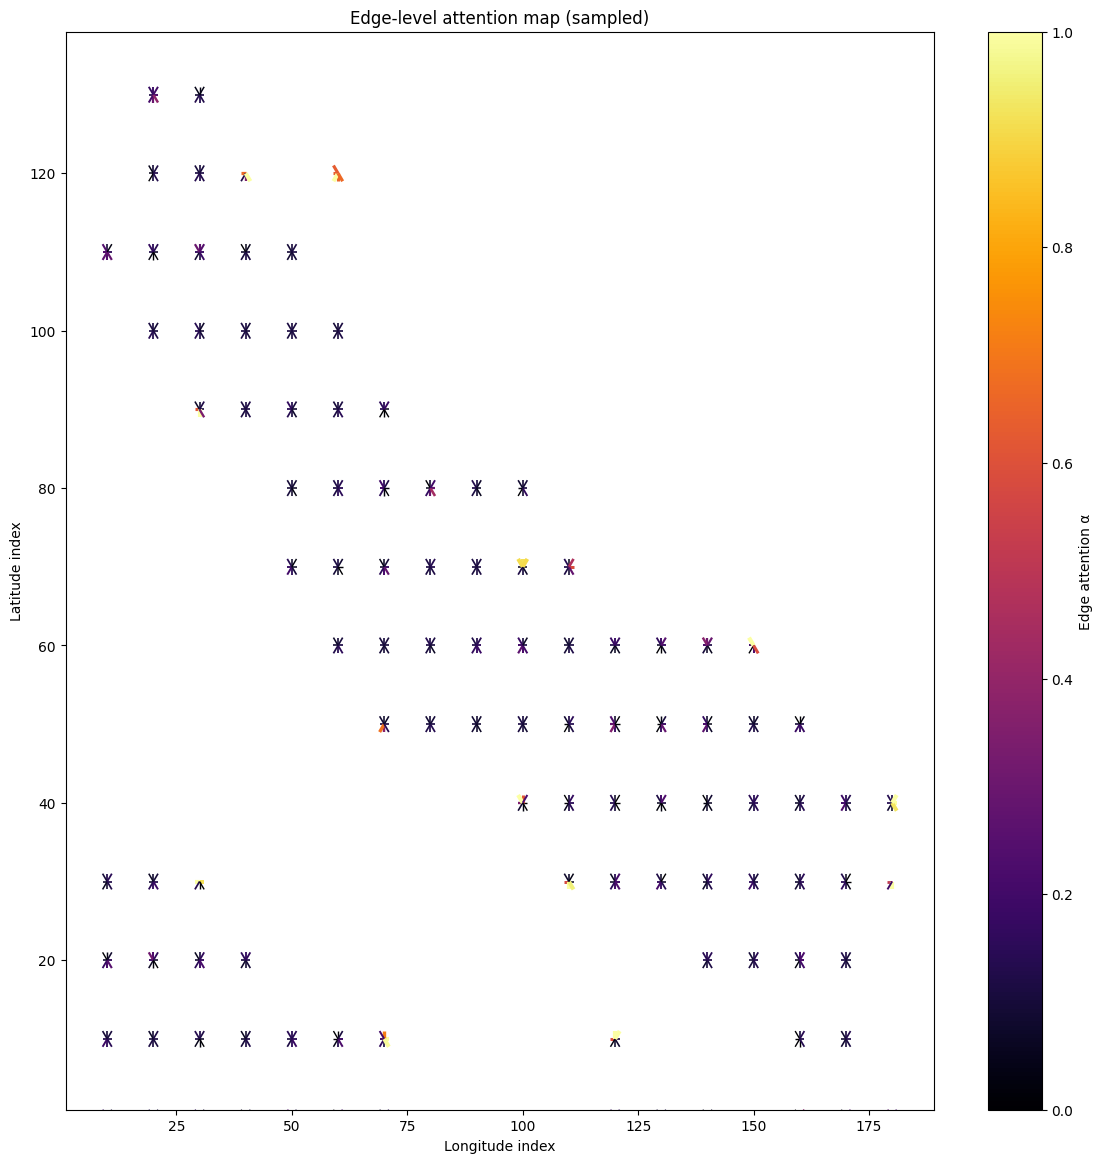

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

step = 10
n_lat = max(r for r, c in grid.keys()) + 1
n_lon = max(c for r, c in grid.keys()) + 1

selected_nodes = [node_id for node_id, (r, c) in node_to_coord.items() if r % step == 0 and c % step == 0]

x_start, y_start = [], []
x_end, y_end = [], []
weights = []

for s, d, a in zip(edge_idx[0], edge_idx[1], attn["gat1"][-1][:,1].cpu().numpy()):#alpha_vals):
    if s in selected_nodes:
        col_s, row_s,  = node_to_coord[s]
        col_d, row_d = node_to_coord[d]
        x_start.append(col_s)
        y_start.append(row_s)
        x_end.append(col_d)
        y_end.append(row_d)
        weights.append(a)

segments = [ [(x0, y0), (x1, y1)] for x0, y0, x1, y1 in zip(x_start, y_start, x_end, y_end) ]
weights = np.array(weights)
# weights /= weights.max()  #  0-1
vmin, vmax = np.percentile(weights, [5, 95])
weights = np.clip((weights - vmin) / (vmax - vmin + 1e-8), 0, 1)

lc = LineCollection(segments, cmap='inferno', linewidths=1 + 2 * weights)
lc.set_array(weights)

plt.figure(figsize=(14, 14))
plt.gca().add_collection(lc)
plt.xlim(1, n_lat)
plt.ylim(1, n_lon)

plt.colorbar(lc, label='Edge attention α')
plt.title('Edge-level attention map (sampled)')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.show()


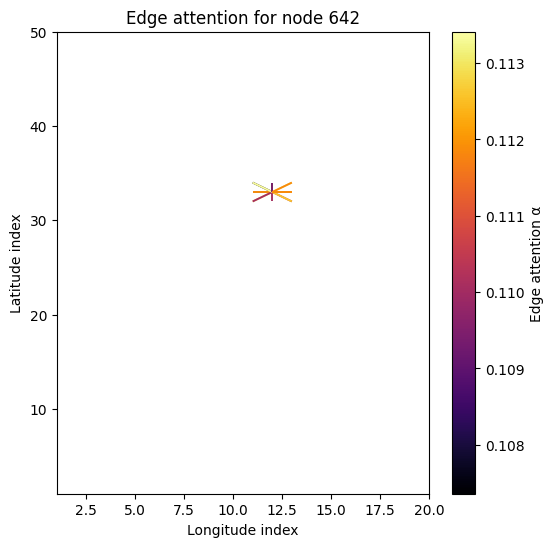

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

node_id = 642 

x_start, y_start = [], []
x_end, y_end = [], []
weights = []

for s, d, a in zip(edge_idx[0], edge_idx[1], attn["gat1"][-1][:,1].cpu().numpy()):
    if s == node_id or d == node_id:  
        col_s, row_s = node_to_coord[s]
        col_d, row_d = node_to_coord[d]
        x_start.append(col_s)
        y_start.append(row_s)
        x_end.append(col_d)
        y_end.append(row_d)
        weights.append(a)

segments = [ [(x0, y0), (x1, y1)] for x0, y0, x1, y1 in zip(x_start, y_start, x_end, y_end) ]
weights = np.array(weights)
# weights /= weights.max()  # normalizacja 0-1

lc = LineCollection(segments, cmap='inferno', linewidths=1 + weights*3)
lc.set_array(weights)

plt.figure(figsize=(6, 6))
plt.gca().add_collection(lc)
plt.xlim(1, 20)
plt.ylim(1, 50)
# plt.gca().invert_yaxis()
plt.colorbar(lc, label='Edge attention α')
plt.title(f'Edge attention for node {node_id}')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.show()


In [197]:
node_importance = np.zeros(N)
node_degree = np.zeros(N)

for s, d, a in zip(src, dst, attn["gat1"][-1][:,0].cpu().numpy()):
    node_importance[s] += a
    node_degree[s] += 1

node_importance /= (node_degree + 1e-8)
node_importance /= node_importance.max() + 1e-8


# node_importance = np.zeros(N)
# node_degree = np.zeros(N)

# for s, d, a in zip(src, dst, attn["gat1"][-1][:,1].cpu().numpy()):
#     node_importance[d] += a
#     node_degree[d] += 1

# node_importance /= (node_degree + 1e-8)
# node_importance /= node_importance.max() + 1e-8



In [198]:
max_x = max(k[0] for k in grid.keys())
max_y = max(k[1] for k in grid.keys())

print("max_x:", max_x)
print("max_y:", max_y)


max_x: 188
max_y: 137


In [199]:
importance_map = np.zeros((max_x+1, max_y+1))


In [200]:
for (col, row), node_id in grid.items():
    importance_map[col, row] = node_importance[node_id]


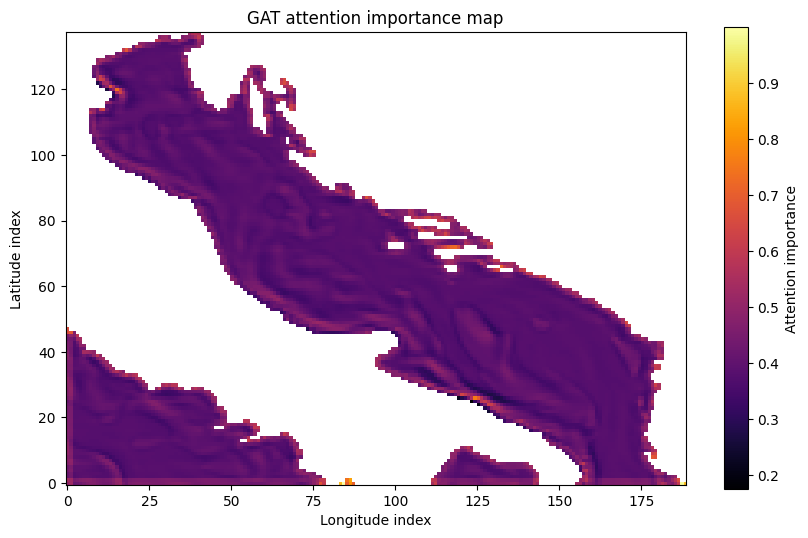

In [201]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

masked_map = np.ma.masked_equal(importance_map, 0)  # mask zeros

plt.figure(figsize=(10, 6))
plt.imshow(
    masked_map.T,
    origin="lower",
    cmap="inferno",
    interpolation="nearest",
    # vmin=0.9999, vmax=1.0
)
plt.colorbar(label="Attention importance")
plt.title("GAT attention importance map")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()


## Multi-step evaluation
Evaluate autoregressive performance across prediction horizons.


X_val_multi: torch.Size([90, 10, 10651, 6])
Y_val_multi: torch.Size([90, 10, 10651, 6])

=== AUTOREGRESSIVE EVALUATION ===

Step 1/10 | R² U: 0.8560, V: 0.7947 | RMSE U: 0.333015, V: 0.416600
Step 2/10 | R² U: 0.6911, V: 0.5618 | RMSE U: 0.489440, V: 0.610820
Step 3/10 | R² U: 0.6049, V: 0.4561 | RMSE U: 0.555172, V: 0.683086
Step 4/10 | R² U: 0.5572, V: 0.3946 | RMSE U: 0.590257, V: 0.725264
Step 5/10 | R² U: 0.5219, V: 0.3470 | RMSE U: 0.615968, V: 0.757170
Step 6/10 | R² U: 0.4824, V: 0.3021 | RMSE U: 0.643192, V: 0.781181
Step 7/10 | R² U: 0.4379, V: 0.2445 | RMSE U: 0.671388, V: 0.812962
Step 8/10 | R² U: 0.3950, V: 0.1892 | RMSE U: 0.699670, V: 0.846310
Step 9/10 | R² U: 0.3650, V: 0.1493 | RMSE U: 0.719105, V: 0.869902
Step 10/10 | R² U: 0.3401, V: 0.1136 | RMSE U: 0.735482, V: 0.890353


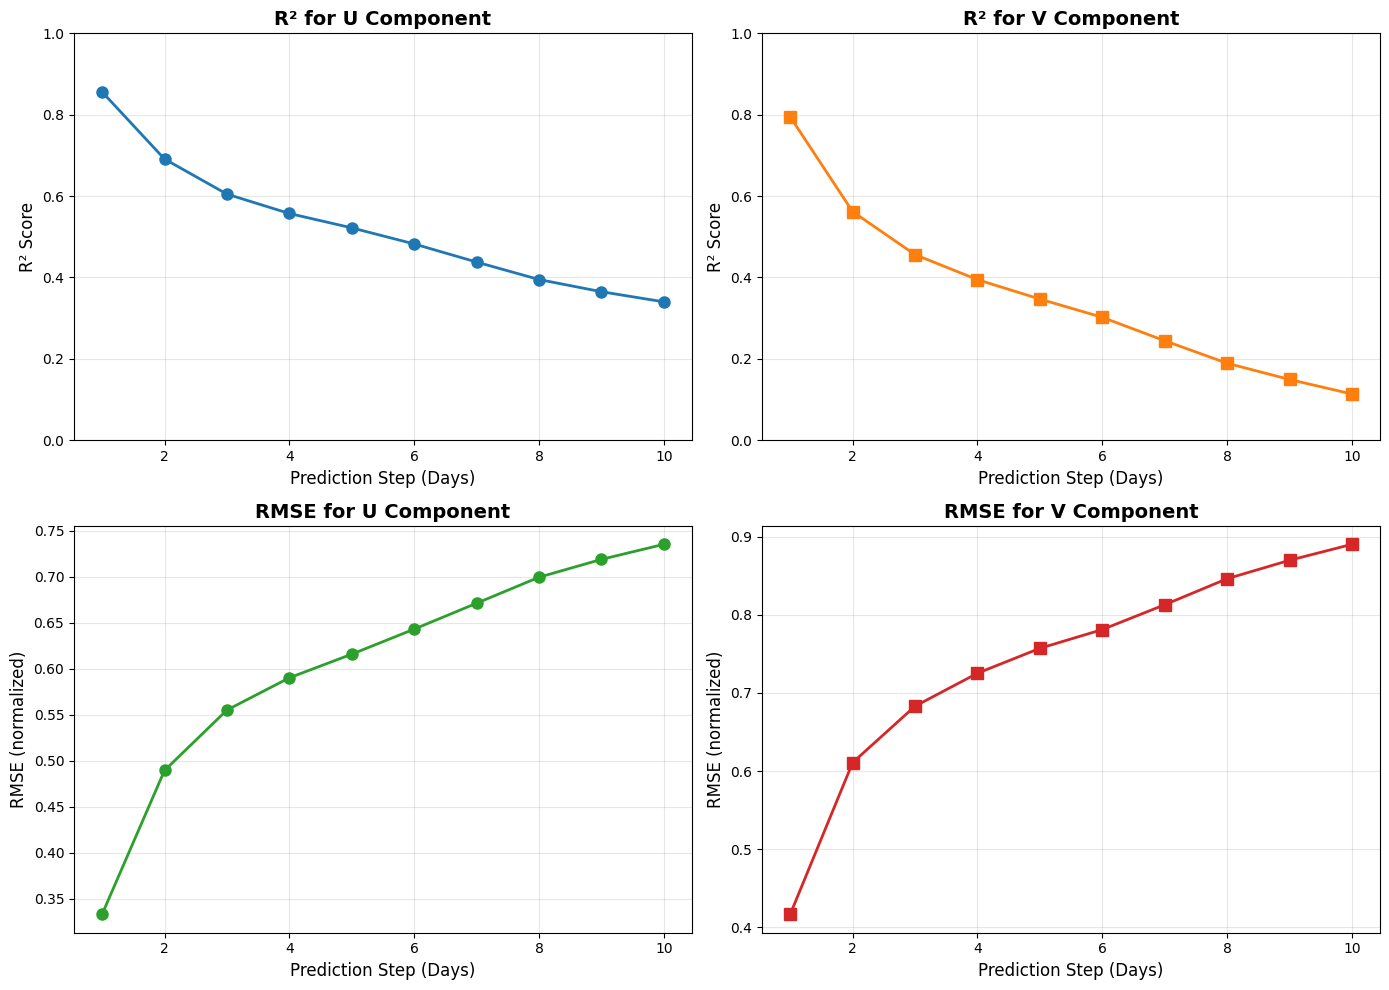

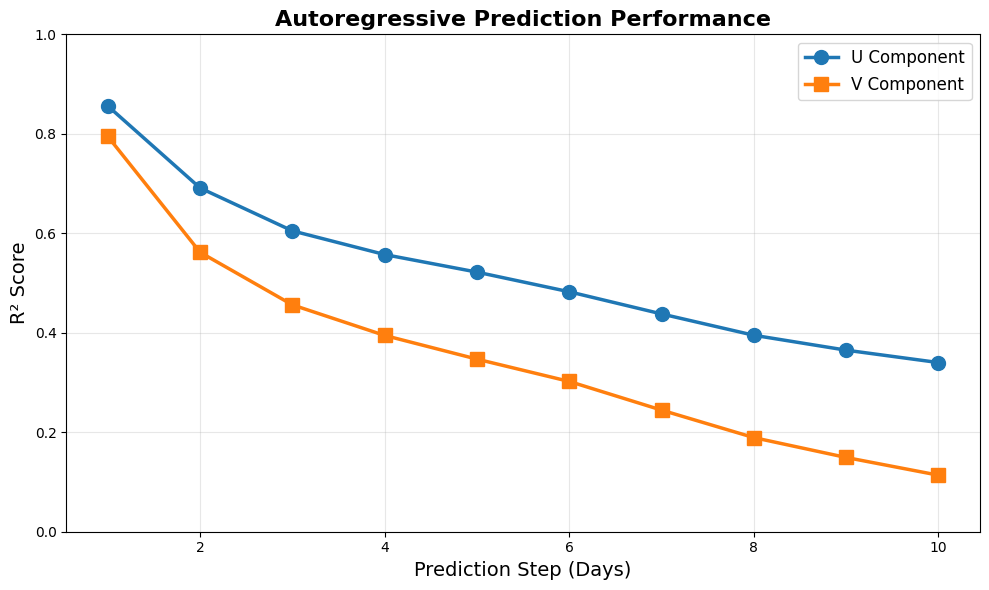


=== SUMMARY ===
Average R² U: 0.5251 ± 0.1519
Average R² V: 0.3553 ± 0.1977
Average RMSE U: 0.605269 ± 0.116200
Average RMSE V: 0.739365 ± 0.135212


In [ ]:
import torch
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# ===========================
# AUTOREGRESSIVE PREDICTION
# ===========================

def autoregressive_prediction(model, x_init, edge_index, device, num_steps=10):
    model.eval()
    predictions = []
    x_current = x_init.clone()
    
    with torch.no_grad():
        for step in range(num_steps):
            pred = model(x_current, edge_index)
            
            # Handle GAT tuple output
            if isinstance(pred, tuple):
                pred = pred[0]
            
            predictions.append(pred[0].cpu())
            
            # Update sequence: remove oldest, add newest
            x_current = torch.cat([
                x_current[:, 1:, :, :],
                pred.unsqueeze(1)
            ], dim=1)
    
    return predictions

# ===========================
# MULTI-STEP SEQUENCES
# ===========================

def create_multi_step_sequences(all_X_norm, seq_len=10, pred_steps=10):
    T = len(all_X_norm)
    sequences_x = []
    sequences_y = []
    
    for i in range(seq_len, T - pred_steps + 1):
        x_seq = all_X_norm[i - seq_len:i]
        y_seq = all_X_norm[i:i + pred_steps]
        sequences_x.append(x_seq)
        sequences_y.append(y_seq)
    
    return torch.stack(sequences_x), torch.stack(sequences_y)

# ===========================
# FIX MODEL FORWARD
# ===========================

class STGAT_Fixed(nn.Module):
    def __init__(self, in_channels=6, hidden_channels=64, out_channels=6, seq_len=10, num_heads=4, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        
        self.gat1 = GATConv(in_channels, hidden_channels, heads=num_heads, dropout=dropout)
        self.gat2 = GATConv(hidden_channels * num_heads, hidden_channels, heads=1, dropout=dropout)
        
        self.gru = nn.GRU(hidden_channels, hidden_channels, batch_first=True)
        self.fc = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, edge_attr=None):
        batch_size, seq_len, N, F = x.shape
        temporal_feats = []
        
        for t in range(seq_len):
            x_t = x[:, t, :, :]
            x_flat = x_t.reshape(batch_size * N, F)
            
            # GAT1 - handle tuple output
            h = self.gat1(x_flat, edge_index)
            if isinstance(h, tuple):
                h = h[0]
            h = torch.relu(h)
            
            # GAT2 - handle tuple output
            h = self.gat2(h, edge_index)
            if isinstance(h, tuple):
                h = h[0]
            h = torch.relu(h)
            
            h = h.reshape(batch_size, N, -1)
            temporal_feats.append(h)
        
        h_seq = torch.stack(temporal_feats, dim=1)
        
        batch_size, seq_len, N, hidden = h_seq.shape
        h_seq = h_seq.permute(0, 2, 1, 3)
        h_seq = h_seq.reshape(batch_size * N, seq_len, hidden)
        
        _, h_last = self.gru(h_seq)
        h_last = h_last.squeeze(0).reshape(batch_size, N, hidden)
        
        out = self.fc(h_last)
        return out

# Load trained model weights into fixed architecture
model_fixed = STGAT_Fixed(in_channels=6, hidden_channels=32, out_channels=6, seq_len=10, num_heads=2)
model_fixed.load_state_dict(model.state_dict())
model_fixed = model_fixed.to(device)

# ===========================
# EVALUATION
# ===========================

def evaluate_autoregressive(model, X_seq, Y_seq, edge_index, device, pred_steps=10, batch_size=4):
    """
    X_seq: (num_samples, seq_len, N, 6)
    Y_seq: (num_samples, pred_steps, N, 6)
    """
    model.eval()
    
    r2_u_per_step = []
    r2_v_per_step = []
    rmse_u_per_step = []
    rmse_v_per_step = []
    
    num_samples = X_seq.shape[0]
    
    for step in range(pred_steps):
        all_pred_u = []
        all_pred_v = []
        all_true_u = []
        all_true_v = []
        
        for i in range(0, num_samples, batch_size):
            batch_x = X_seq[i:i+batch_size].to(device)
            batch_y = Y_seq[i:i+batch_size, step].cpu().numpy()
            
            # Autoregressive prediction up to step
            x_current = batch_x.clone()
            
            with torch.no_grad():
                for s in range(step + 1):
                    pred = model(x_current, edge_index)
                    
                    if isinstance(pred, tuple):
                        pred = pred[0]
                    
                    if s < step:
                        x_current = torch.cat([
                            x_current[:, 1:, :, :],
                            pred.unsqueeze(1)
                        ], dim=1)
            
            pred_np = pred.cpu().numpy()
            
            all_pred_u.append(pred_np[:, :, 0])
            all_pred_v.append(pred_np[:, :, 1])
            all_true_u.append(batch_y[:, :, 0])
            all_true_v.append(batch_y[:, :, 1])
            
            torch.cuda.empty_cache()
        
        # Flatten
        pred_u = np.concatenate(all_pred_u).flatten()
        pred_v = np.concatenate(all_pred_v).flatten()
        true_u = np.concatenate(all_true_u).flatten()
        true_v = np.concatenate(all_true_v).flatten()
        
        # Metrics
        r2_u = r2_score(true_u, pred_u)
        r2_v = r2_score(true_v, pred_v)
        rmse_u = np.sqrt(np.mean((true_u - pred_u)**2))
        rmse_v = np.sqrt(np.mean((true_v - pred_v)**2))
        
        r2_u_per_step.append(r2_u)
        r2_v_per_step.append(r2_v)
        rmse_u_per_step.append(rmse_u)
        rmse_v_per_step.append(rmse_v)
        
        print(f"Step {step+1}/{pred_steps} | R² U: {r2_u:.4f}, V: {r2_v:.4f} | RMSE U: {rmse_u:.6f}, V: {rmse_v:.6f}")
    
    return r2_u_per_step, r2_v_per_step, rmse_u_per_step, rmse_v_per_step

# ===========================
# RUN
# ===========================

pred_steps = 10

# Create multi-step validation sequences
val_start = train_size
val_end = train_size + val_size

X_val_multi, Y_val_multi = create_multi_step_sequences(
    all_X_norm[val_start:val_end], 
    seq_len=10, 
    pred_steps=pred_steps
)

print(f"X_val_multi: {X_val_multi.shape}")
print(f"Y_val_multi: {Y_val_multi.shape}\n")

# Evaluate
print("=== AUTOREGRESSIVE EVALUATION ===\n")
r2_u_steps, r2_v_steps, rmse_u_steps, rmse_v_steps = evaluate_autoregressive(
    model_fixed, X_val_multi, Y_val_multi, edge_index, device, pred_steps=pred_steps
)

# ===========================
# VISUALIZATION
# ===========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# R² U
axes[0, 0].plot(range(1, pred_steps+1), r2_u_steps, 'o-', linewidth=2, markersize=8, color='#1f77b4')
axes[0, 0].set_xlabel('Prediction Step (Days)', fontsize=12)
axes[0, 0].set_ylabel('R² Score', fontsize=12)
axes[0, 0].set_title('R² for U Component', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# R² V
axes[0, 1].plot(range(1, pred_steps+1), r2_v_steps, 's-', linewidth=2, markersize=8, color='#ff7f0e')
axes[0, 1].set_xlabel('Prediction Step (Days)', fontsize=12)
axes[0, 1].set_ylabel('R² Score', fontsize=12)
axes[0, 1].set_title('R² for V Component', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_ylim([0, 1])

# RMSE U
axes[1, 0].plot(range(1, pred_steps+1), rmse_u_steps, 'o-', linewidth=2, markersize=8, color='#2ca02c')
axes[1, 0].set_xlabel('Prediction Step (Days)', fontsize=12)
axes[1, 0].set_ylabel('RMSE (normalized)', fontsize=12)
axes[1, 0].set_title('RMSE for U Component', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# RMSE V
axes[1, 1].plot(range(1, pred_steps+1), rmse_v_steps, 's-', linewidth=2, markersize=8, color='#d62728')
axes[1, 1].set_xlabel('Prediction Step (Days)', fontsize=12)
axes[1, 1].set_ylabel('RMSE (normalized)', fontsize=12)
axes[1, 1].set_title('RMSE for V Component', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('autoregressive_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Combined R² plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, pred_steps+1), r2_u_steps, 'o-', label='U Component', linewidth=2.5, markersize=10)
plt.plot(range(1, pred_steps+1), r2_v_steps, 's-', label='V Component', linewidth=2.5, markersize=10)
plt.xlabel('Prediction Step (Days)', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.title('Autoregressive Prediction Performance', fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.ylim([0, 1])
plt.tight_layout()
plt.savefig('r2_combined.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n=== SUMMARY ===")
print(f"Average R² U: {np.mean(r2_u_steps):.4f} ± {np.std(r2_u_steps):.4f}")
print(f"Average R² V: {np.mean(r2_v_steps):.4f} ± {np.std(r2_v_steps):.4f}")
print(f"Average RMSE U: {np.mean(rmse_u_steps):.6f} ± {np.std(rmse_u_steps):.6f}")
print(f"Average RMSE V: {np.mean(rmse_v_steps):.6f} ± {np.std(rmse_v_steps):.6f}")